## Regresión Polinómica

---
### 📋 Descripción del notebook

La **regresión polinómica** extiende la regresión lineal añadiendo potencias e interacciones de las variables originales como nuevas features. Aunque el modelo sigue siendo *lineal en los parámetros*, es capaz de capturar relaciones **no lineales** entre predictores y variable objetivo.

**Idea clave:**

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \ldots$$

Usaremos el mismo dataset de viviendas de EE.UU. (`USA_Housing.csv`) del notebook anterior para poder **comparar directamente** con los resultados de la regresión lineal clásica.

**Estructura:**
1. Carga y exploración del dataset
2. Transformación polinómica de features con `PolynomialFeatures`
3. Entrenamiento con `LinearRegression` sobre las features expandidas
4. Evaluación y comparativa con el modelo lineal simple


In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a Python data visualization library based on matplotlib. 
%matplotlib inline  
# Import train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score

Las mismas librerías que en el notebook de regresión lineal. `PolynomialFeatures` y `mean_squared_error` se importarán más adelante, justo antes de usarlas.

#### 0. Importamos datos

In [2]:
os.getcwd()

'c:\\Users\\tomas\\ML\\Master Data Science and AI\\04 Aprendizaje supervisado'

In [3]:
path = 'data\\USA_Housing.csv'
#'C:\\Users\\tomas\\ML\\cluster\\Scripts\\data'

df = pd.read_csv(path)
df.head(5)
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


Cargamos el mismo dataset `USA_Housing.csv` para que los resultados sean **directamente comparables** con los de la regresión lineal clásica. El dataset contiene 5.000 registros de viviendas con sus características de zona y precio.

#### 1. Analizamos los datos

In [4]:
#chequeamos nulos 
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Sin valores nulos: no necesitamos imputación. El dataset está limpio y listo para modelar.

In [5]:
#quito las variables categoricas 
df2 = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population', 'Price' ]]
df2

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


Descartamos `Address` (texto libre) y nos quedamos con las 5 variables numéricas como predictores y `Price` como objetivo, igual que en el notebook anterior.

<Axes: >

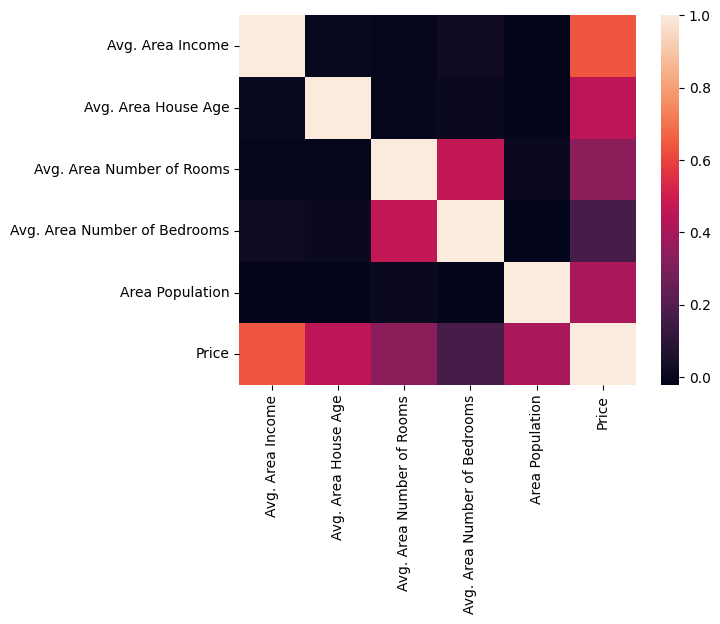

In [6]:
# heatmap de correlaciones
sns.heatmap(df2.corr())

El heatmap confirma las correlaciones entre variables. Nos interesa la columna `Price`: las variables con mayor correlación con el precio serán los predictores más influyentes.

> 💡 En la regresión polinómica de grado 2 también se añadirán los cuadrados e interacciones de estas variables, por lo que el modelo podrá capturar efectos que aquí no son visibles.


In [7]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']

Separamos `X` (5 features) e `y` (`Price`). Estas variables son la base: `PolynomialFeatures` las transformará en un espacio de mayor dimensión.

#### 2. Modelo: Regresión polinómica
La regresion polinomica en el fondo se rtrata de una regresion lineal donde hemos añadido features nuevas que son las actuales evelvas al cuadrado, al cubo etc.

In [8]:
# Split up the data into a training set
#random state es una vaor semilla para hacer la separaciion. Hace que cada vez que lo ejecutemos los conjuntos de entrenaiento y tes sean los mismos 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

Misma partición train/test que en el notebook de regresión lineal (60% / 40%, `random_state=101`) para garantizar la **comparabilidad de resultados**.

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
poly = PolynomialFeatures(degree=2)
#poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


#X[0]


---
#### ¿Qué hace `PolynomialFeatures(degree=2)`?

Transforma las 5 features originales en un espacio de mayor dimensión que incluye:
- El término constante (bias)
- Las 5 features originales: $x_1, x_2, x_3, x_4, x_5$
- Sus cuadrados: $x_1^2, x_2^2, \ldots, x_5^2$
- Todas las interacciones cruzadas: $x_1 x_2, x_1 x_3, \ldots, x_4 x_5$

Con 5 variables y grado 2, el número de features resultante es:

$$\binom{5+2}{2} = 21 \text{ features}$$

**Regla de oro:**
- `fit_transform` sobre **train**: ajusta el transformador Y transforma
- `transform` sobre **test**: solo transforma (sin reajustar) → evita *data leakage*

> ⚠️ Con `degree=10` el número de features explotaría y el modelo casi con seguridad sobreajustaría.


In [10]:
X_train_poly[0]

array([1.00000000e+00, 6.80911797e+04, 5.36420804e+00, 7.50295579e+00,
       3.10000000e+00, 4.45573797e+04, 4.63640875e+09, 3.65255253e+05,
       5.10885111e+05, 2.11082657e+05, 3.03396454e+09, 2.87747279e+01,
       4.02474158e+01, 1.66290449e+01, 2.39015054e+05, 5.62943457e+01,
       2.32591630e+01, 3.34312050e+05, 9.61000000e+00, 1.38127877e+05,
       1.98536008e+09])

Visualizamos la primera fila transformada para ver concretamente cómo `PolynomialFeatures` expande las 5 variables originales en las 21 nuevas features (incluido el término constante 1.0 al inicio).

In [11]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predicciones en el conjunto de prueba
y_pred_poly = model.predict(X_test_poly)
y_pred_poly_train = model.predict(X_train_poly)

El `LinearRegression` ve ahora una matriz de 21 columnas en lugar de 5. **El algoritmo sigue siendo el mismo** (mínimos cuadrados ordinarios), pero opera sobre el espacio expandido.

Guardamos predicciones tanto en **test** (`y_pred_poly`) como en **train** (`y_pred_poly_train`) para poder detectar sobreajuste comparando R² en ambos conjuntos.


In [12]:
print("poly MSE:", mean_squared_error(y_test, y_pred_poly))
r2_=r2_score(y_test, y_pred_poly)
print("R2:", r2_)
r2_train=r2_score(y_train, y_pred_poly_train)
print("R2 train:", r2_train)


poly MSE: 10556860780.828245
R2: 0.9169277462483414
R2 train: 0.9185581487811313


---
**Interpretación de los resultados:**

Compara estos valores con los del modelo lineal simple:

| Métrica | Lineal simple | Polinómico grado 2 |
|---|---|---|
| R² test | ~0.92 | ? |
| R² train | ~0.92 | ? |

- Si **R²_train >> R²_test** → el modelo está **sobreajustando**: ha memorizado el train pero no generaliza
- Si **R²_train ≈ R²_test** y ambos mejoran respecto al lineal → la expansión polinómica ha capturado relaciones no lineales reales
- Si el aumento de R² es mínimo → el dataset ya es bien lineal y el polinómico no aporta nada significativo


In [13]:
print("Coeficientes:", model.coef_)
print("Intercept:", model.intercept_)

Coeficientes: [ 0.00000000e+00  2.12635772e+01  1.33219388e+05  7.89119544e+04
  2.55251663e+04  1.32809109e+01  1.85985795e-06 -6.07820941e-02
 -1.80931630e-01  1.45945324e-01  2.89648787e-05  2.55873457e+03
  3.47563660e+03 -3.48271963e+03 -1.41860475e-01  1.94576490e+03
  4.09707879e+02  1.72285318e-01 -1.01405950e+03 -1.86729407e-01
  3.82664727e-06]
Intercept: -2401601.6159293368


Con grado 2 tenemos **21 coeficientes**. A diferencia de la regresión lineal simple, aquí la interpretabilidad individual de cada coeficiente es más difícil porque están asociados a combinaciones (como $x_1 \cdot x_3$ o $x_2^2$), no a variables originales directamente.

> 💡 En la práctica, cuando el interés principal es la predicción y no la interpretación, el mayor número de coeficientes no es un problema. Pero si necesitas explicar el modelo a negocio, la regresión lineal simple suele ser preferible.


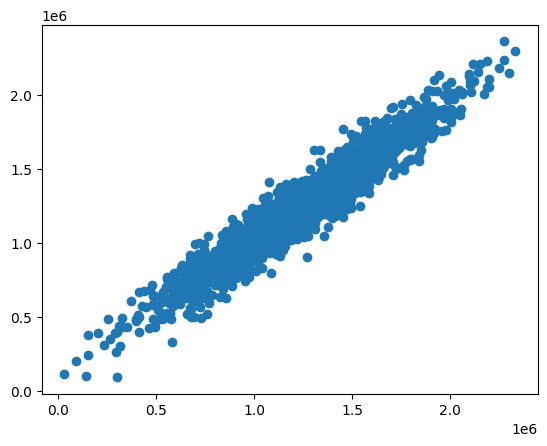

In [14]:
# y estimada vs y real
plt.scatter(y_test,y_pred_poly )

**Gráfico: valores predichos vs. valores reales**

Compara visualmente esta nube de puntos con la del modelo lineal:
- Una nube más compacta en torno a la diagonal → mejor ajuste
- Patrones sistemáticos (curvas, embudos) → el modelo aún no captura bien alguna estructura de los datos


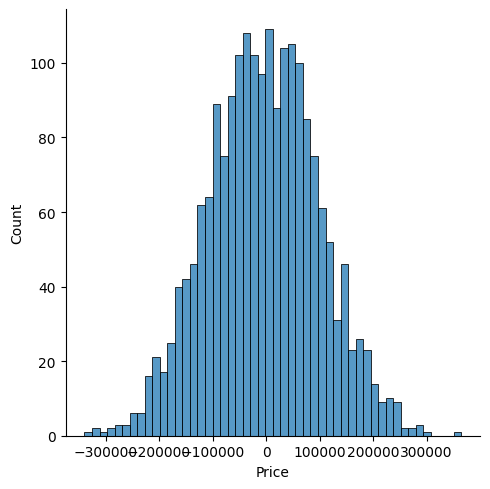

In [15]:
# histograma de residuales
sns.displot((y_test-y_pred_poly),bins=50)

**Histograma de residuales**

Si el grado polinómico es el adecuado, los residuales deberían seguir siendo aproximadamente normales y centrados en 0. Un exceso de colas asimétricas o un desplazamiento del centro indicaría que el grado elegido no es suficiente (o que hay otras fuentes de variabilidad no capturadas).

---
> **Conclusión del notebook:**
> La regresión polinómica de grado 2 añade 16 features adicionales (cuadrados e interacciones) sobre las 5 originales.
> Si el R² mejora notablemente respecto al modelo lineal, existe no-linealidad real en los datos.
> Si apenas mejora (como ocurre en este dataset bastante lineal), el coste en complejidad e interpretabilidad no se justifica.
> El riesgo clave a vigilar siempre es el **sobreajuste**: un grado alto puede memorizar el ruido del train.
